# Linear Regression Learning Goals

This notebook is designed to cover a comprehensive set of learning goals for linear regression—from fundamental concepts to advanced topics. The notebook covers the following topics:

1. **Fundamental Concepts**
   - Linear regression model: hypothesis, model representation (`y = β₀ + β₁x`), and multiple regression extension.
   - Key assumptions: linearity, independence of errors, homoscedasticity, normality of errors, absence of perfect multicollinearity.
   - Mathematical foundations: basic statistics (mean, variance, correlation) and linear algebra (vectors, matrices, and operations).

2. **Estimation Techniques & Optimization**
   - Ordinary Least Squares (OLS) and derivation of the normal equations (closed-form solution).
   - Iterative optimization methods: gradient descent, stochastic gradient descent, mini-batch gradient descent.
   - Comparison between closed-form and iterative methods.

3. **Model Evaluation & Diagnostics**
   - Evaluation metrics: MSE, RMSE, MAE, R-squared, and Adjusted R-squared.
   - Residual analysis and diagnostic tests (Cook's distance, leverage, variance inflation factor).
   - Hypothesis testing for regression coefficients and constructing confidence intervals.

4. **Regularization & Overfitting Prevention**
   - Regularization techniques: Ridge, Lasso, and Elastic Net.
   - Bias-variance tradeoff and strategies to mitigate overfitting.
   - Robust regression methods (e.g., least absolute deviations) to handle outliers.

5. **Extensions & Non-Linear Models**
   - Polynomial regression and models with interaction terms.
   - Generalized Linear Models (GLMs), including logistic regression for classification tasks.
   - Kernel methods and non-linear transformations to model complex relationships.

6. **Implementation & Practical Applications**
   - Implement linear regression using Python libraries (scikit-learn and statsmodels).
   - Integration into broader machine learning pipelines.
   - Application to real-world problems (forecasting, trend analysis, risk modeling, etc.).

7. **Advanced Theoretical Topics**
   - Statistical properties: Gauss–Markov theorem, consistency, efficiency, and asymptotic behavior of estimators.
   - Bayesian linear regression and methods for uncertainty quantification.
   - High-dimensional linear regression challenges (feature selection, handling multicollinearity).

8. **Research & Case Studies**
   - Analyze academic papers and case studies on linear regression applications across various domains.
   - Projects and competitions to refine your skills and critically assess the limitations of linear regression.

Let's dive in!

## 1. Fundamental Concepts

### Model Representation

We start with the simple linear regression model:

$
y = \beta_0 + \beta_1 x
$

and extend it to multiple regression:

$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$

### Key Assumptions

1. **Linearity:** The relationship between predictors and response is linear.
2. **Independence:** Observations (and errors) are independent.
3. **Homoscedasticity:** Constant variance of errors.
4. **Normality of Errors:** The error terms are normally distributed.
5. **No Perfect Multicollinearity:** Predictors are not perfectly correlated.

### Mathematical Foundations

- **Basic statistics:** Mean, variance, correlation.
- **Linear algebra:** Understanding vectors, matrices, and their operations is essential for deriving OLS solutions.

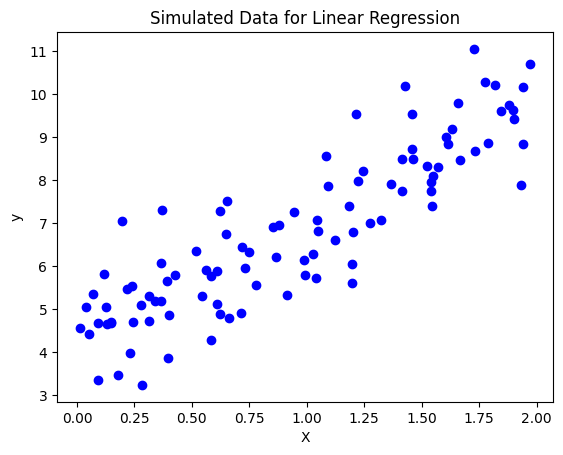

In [1]:
# Let's simulate some simple data for a univariate regression
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + noise

plt.scatter(X, y, color='blue')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Simulated Data for Linear Regression')
plt.show()

## 2. Estimation Techniques & Optimization

### Ordinary Least Squares (OLS)

OLS finds the parameters that minimize the sum of squared errors. The closed-form solution is given by the normal equations:
$
 ( \hat{\beta} = (X^TX)^{-1}X^Ty ). 
$
Let's compute this solution using NumPy.

In [3]:
# Add a bias (intercept) term to X
X_b = np.c_[np.ones((100, 1)), X]  

# Compute the OLS solution using the normal equation
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print("OLS parameters (intercept, slope):", theta_best.ravel())

OLS parameters (intercept, slope): [4.21509616 2.77011339]


### Iterative Optimization: Gradient Descent

Below is an implementation of gradient descent to estimate the regression parameters.

In [4]:
eta = 0.1  # learning rate
n_iterations = 1000
m = 100

theta = np.random.randn(2,1)  # random initialization

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

print("Gradient Descent parameters:", theta.ravel())

Gradient Descent parameters: [4.21509616 2.77011339]


## 3. Model Evaluation & Diagnostics

### Evaluation Metrics

We compute metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared.

### Residual Analysis & Diagnostics

We'll review residual plots and compute diagnostic measures (for example, leverage or VIF can be computed using statsmodels or custom code).

MSE: 0.807
RMSE: 0.898
MAE: 0.701
R-squared: 0.769


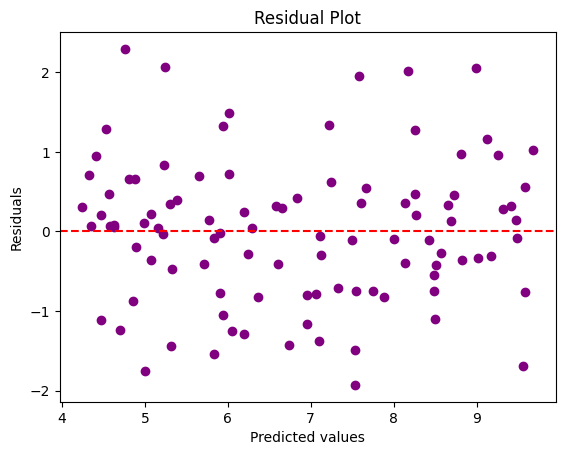

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions using OLS parameters
y_pred = X_b.dot(theta_best)

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R-squared: {r2:.3f}")

# Residual plot
residuals = y - y_pred
plt.scatter(y_pred, residuals, color='purple')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

## 4. Regularization & Overfitting Prevention

We now apply regularization techniques to prevent overfitting. We demonstrate Ridge, Lasso, and Elastic Net using scikit-learn.

Also, note that robust regression methods (e.g., least absolute deviations) can be used to handle outliers.

In [6]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# For demonstration, we use the same simulated data

# Ridge Regression
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_b, y)
print("Ridge parameters:", ridge_reg.coef_.ravel(), "Intercept:", ridge_reg.intercept_[0])

# Lasso Regression
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_b, y.ravel())
print("Lasso parameters:", lasso_reg.coef_, "Intercept:", lasso_reg.intercept_)

# Elastic Net
elastic_reg = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_reg.fit(X_b, y.ravel())
print("Elastic Net parameters:", elastic_reg.coef_, "Intercept:", elastic_reg.intercept_)

Ridge parameters: [0.         2.69326395] Intercept: 4.28736241130523
Lasso parameters: [0.         2.48477396] Intercept: 4.483418368806452
Elastic Net parameters: [0.         2.29939031] Intercept: 4.657746009455282


## 5. Extensions & Non-Linear Models

### Polynomial Regression

We extend our linear model by including polynomial features and interaction terms.

### Generalized Linear Models (GLMs)

For example, logistic regression is a GLM used for classification. Kernel methods and other non-linear transformations can model complex relationships.

Below is an example of Polynomial Regression using scikit-learn.

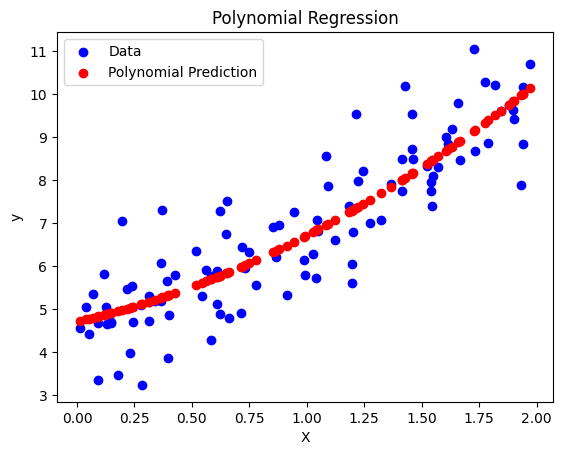

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create a polynomial regression model (degree 2)
poly_model = make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0))
poly_model.fit(X, y)

# Predict using the polynomial model
y_poly_pred = poly_model.predict(X)

plt.scatter(X, y, color='blue', label='Data')
plt.scatter(X, y_poly_pred, color='red', label='Polynomial Prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.legend()
plt.show()

## 6. Implementation & Practical Applications

### Using scikit-learn & statsmodels

We demonstrate implementation using both scikit-learn and statsmodels. Statsmodels gives detailed statistical summaries.

Below is an example using statsmodels for OLS.

In [8]:
import statsmodels.api as sm

# Fit OLS model using statsmodels
X_sm = sm.add_constant(X)  # add intercept
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     326.7
Date:                Wed, 26 Mar 2025   Prob (F-statistic):           5.66e-33
Time:                        17:20:07   Log-Likelihood:                -131.15
No. Observations:                 100   AIC:                             266.3
Df Residuals:                      98   BIC:                             271.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2151      0.170     24.753      0.0

### Integration in ML Pipelines

Linear regression is widely used in forecasting, trend analysis, and risk modeling. It can be integrated into larger pipelines using scikit-learn’s `Pipeline` class. This notebook demonstrates key techniques, which you can further apply to real-world datasets.

## 7. Advanced Theoretical Topics

### Statistical Properties

Key theoretical topics include:

- **Gauss–Markov Theorem:** Under the classical linear regression assumptions, the OLS estimator is the Best Linear Unbiased Estimator (BLUE).
- **Consistency & Efficiency:** Properties of estimators as sample size grows.
- **Asymptotic Behavior:** Understanding how estimators behave in large samples.

### Bayesian Linear Regression

An alternative approach that incorporates prior beliefs and yields a distribution over parameters for uncertainty quantification.

### High-Dimensional Challenges

When the number of predictors is large, issues such as multicollinearity arise. Feature selection methods and regularization become essential.

## 8. Research & Case Studies

### Case Studies & Competitions

Explore academic papers and Kaggle competitions to understand how linear regression is applied in domains such as finance, healthcare, and environmental science. Critically assess the limitations and pitfalls in practical scenarios.

Some recommended readings:

- Papers on the application of linear regression in risk modeling.
- Kaggle projects that use linear regression for forecasting and trend analysis.

Engage with case studies to refine your skills and evaluate the assumptions and limitations of the model.

## 9. Project Documentation & Reproducibility

Document every step of your analysis, include code explanations, plots, and results. Use markdown cells for narrative and ensure that your workflow is reproducible. This notebook itself serves as an example of a well-documented project.

## Conclusion

This notebook has demonstrated a complete journey through linear regression learning goals:

- **Fundamental Concepts:** Model representation, assumptions, and mathematical foundations.
- **Estimation Techniques & Optimization:** OLS (closed-form) and iterative gradient descent methods.
- **Model Evaluation & Diagnostics:** Metrics and residual analysis.
- **Regularization & Overfitting Prevention:** Ridge, Lasso, Elastic Net, and robust regression.
- **Extensions & Non-Linear Models:** Polynomial regression, GLMs, and kernel methods.
- **Implementation & Practical Applications:** Examples with scikit-learn and statsmodels, integration into ML pipelines.
- **Advanced Theoretical Topics:** Gauss–Markov theorem, Bayesian regression, and high-dimensional challenges.
- **Research & Case Studies:** Exploration of academic papers and practical projects.


In [ ]:
import requests
import os

def download_images(query, api_key, num_images=5):
    url = 'https://pixabay.com/api/'
    params = {
        'key': api_key,
        'q': query,
        'image_type': 'photo',
        'per_page': num_images
    }
    response = requests.get(url, params=params)
    data = response.json()
    os.makedirs(query, exist_ok=True)
    for idx, hit in enumerate(data['hits']):
        image_url = hit['webformatURL']
        img_data = requests.get(image_url).content
        with open(os.path.join(query, f'image_{idx+1}.jpg'), 'wb') as f:
            f.write(img_data)
    print(f"Downloaded {len(data['hits'])} images for query '{query}'.")

# Example usage:
download_images('puppies', '35167250-dd1466831d2db24ca555df378', num_images=1)
